<a href="https://colab.research.google.com/github/Simpson69-il/DEEPLEARNING5THSEM/blob/main/EXERCISE%204/24BAD074-ex4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

24BAD074 MOHD SHAFIQUE R B

PART A

In [1]:
import tensorflow as tf

print("Downloading TensorFlow Flowers dataset...")

dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)

print("Dataset downloaded successfully!")
print("Location:", data_dir)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Dataset downloaded successfully!
Location: /root/.keras/datasets/flower_photos


In [2]:
import os

data_dir = "/root/.keras/datasets/flower_photos"

print("Dataset location:", data_dir)

for folder in os.listdir(data_dir):
    print(folder)

Dataset location: /root/.keras/datasets/flower_photos
flower_photos


In [3]:
import tensorflow as tf

data_dir = "/root/.keras/datasets/flower_photos/flower_photos"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

print("Classes:", dataset.class_names)

Found 3670 files belonging to 5 classes.
Classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [4]:
# Find total number of batches
total_batches = tf.data.experimental.cardinality(dataset).numpy()

# Calculate split sizes
train_batches = int(0.70 * total_batches)
val_batches = int(0.15 * total_batches)

# Create datasets
train_ds = dataset.take(train_batches)

remaining_ds = dataset.skip(train_batches)

val_ds = remaining_ds.take(val_batches)

test_ds = remaining_ds.skip(val_batches)

print("Total batches:", total_batches)
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Validation batches:", tf.data.experimental.cardinality(val_ds).numpy())
print("Testing batches:", tf.data.experimental.cardinality(test_ds).numpy())

Total batches: 115
Training batches: 80
Validation batches: 17
Testing batches: 18


In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Dataset pipeline optimized.")

Dataset pipeline optimized.


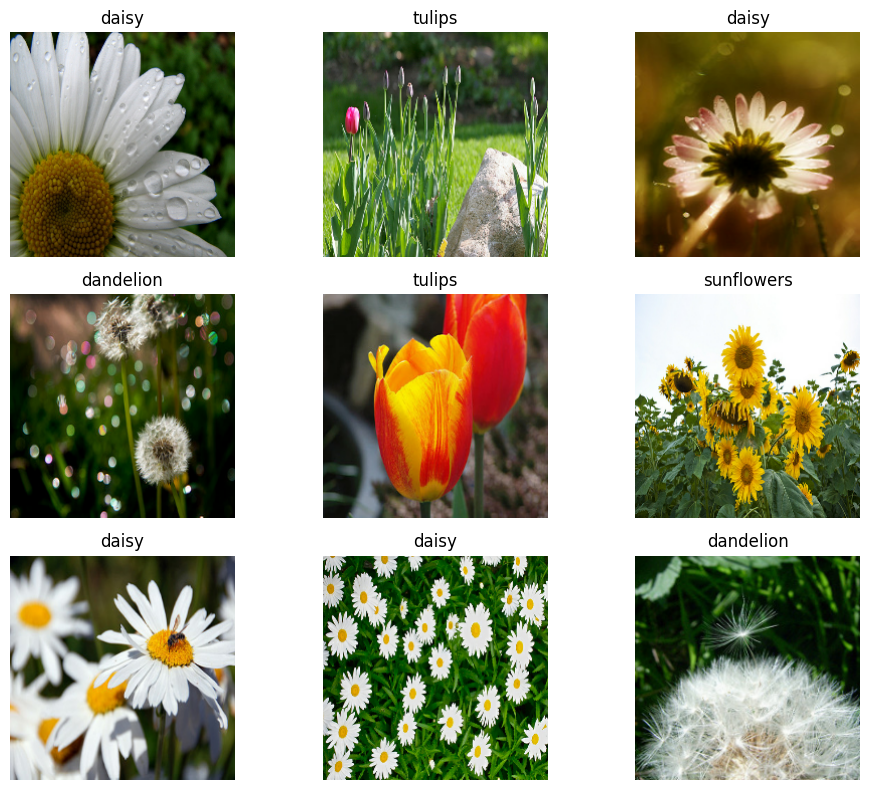

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(dataset.class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

PART B

In [7]:
from tensorflow.keras.applications import ResNet50

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

print("ResNet-50 loaded successfully!")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet-50 loaded successfully!


In [8]:
base_model.trainable = False

print("ResNet-50 layers:", len(base_model.layers))
print("ResNet-50 layers are now frozen.")

ResNet-50 layers: 175
ResNet-50 layers are now frozen.


In [9]:
from tensorflow.keras import layers, models

model = models.Sequential([

    # Pre-trained ResNet-50
    base_model,

    # Convert feature maps into a single feature vector
    layers.GlobalAveragePooling2D(),

    # Reduce overfitting
    layers.Dropout(0.3),

    # Our 5 flower classes
    layers.Dense(5, activation="softmax")
])

print("Transfer learning model created!")

Transfer learning model created!


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │        10,245 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,597,957 (90.02 MB)

 Trainable params: 10,245 (40.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [12]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 31s 203ms/step - accuracy: 0.6660 - loss: 0.9331 - val_accuracy: 0.8438 - val_loss: 0.4633
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 12s 154ms/step - accuracy: 0.8395 - loss: 0.4546 - val_accuracy: 0.8640 - val_loss: 0.4146
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 164ms/step - accuracy: 0.8637 - loss: 0.3750 - val_accuracy: 0.8971 - val_loss: 0.3292
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 19s 233ms/step - accuracy: 0.8746 - loss: 0.3331 - val_accuracy: 0.9026 - val_loss: 0.2933
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 183ms/step - accuracy: 0.8980 - loss: 0.2754 - val_accuracy: 0.9026 - val_loss: 0.2980
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 14s 176ms/step - accuracy: 0.9176 - loss: 0.2305 - val_accuracy: 0.9246 - val_loss: 0.2450
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 165ms/step - accuracy: 0.9344 - loss: 0.2092 - val_accuracy: 0.9062 - val_loss: 0.3037
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 13s 163ms/step - accuracy: 0.9355 - loss: 0.1934 - val_accu

In [13]:
test_loss, test_accuracy = model.evaluate(test_ds)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

18/18 ━━━━━━━━━━━━━━━━━━━━ 10s 360ms/step - accuracy: 0.8763 - loss: 0.3639
Test Loss: 0.36394405364990234
Test Accuracy: 0.8763250708580017


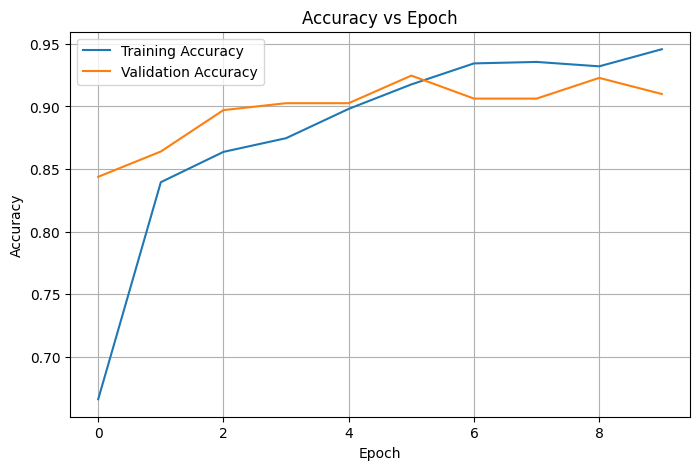

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.legend()
plt.grid()

plt.show()

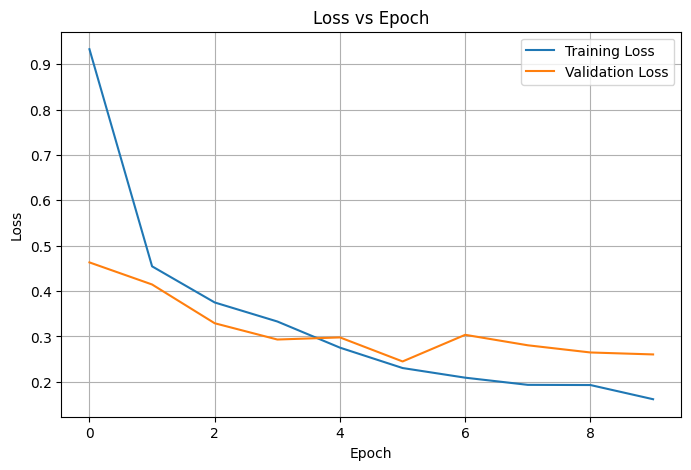

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.legend()
plt.grid()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


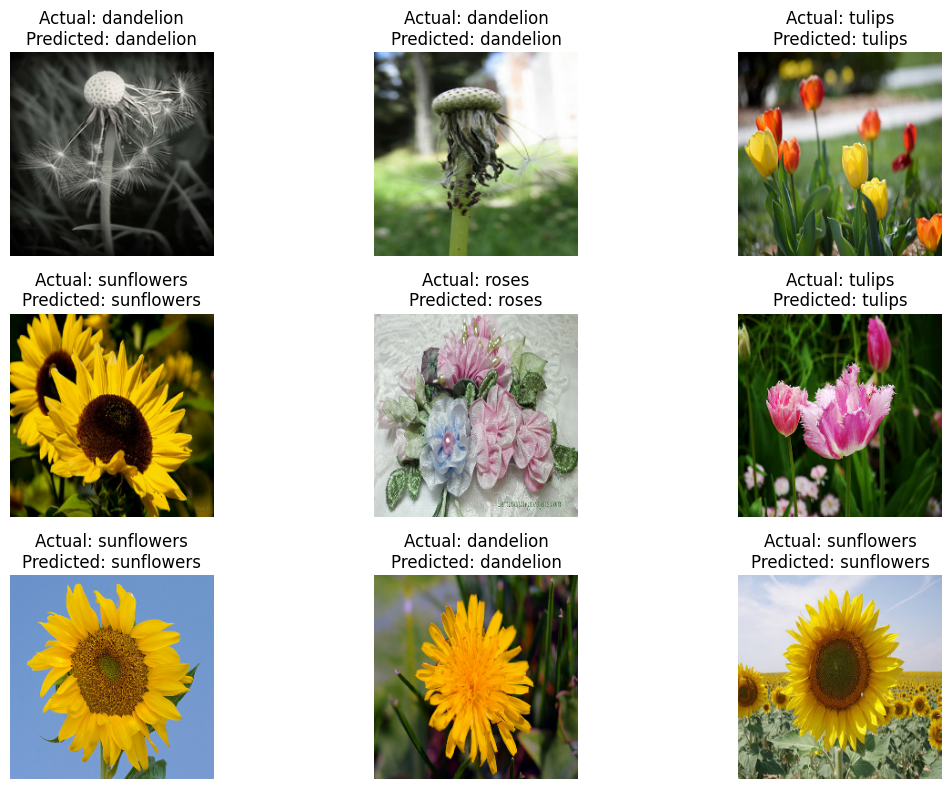

In [16]:
import numpy as np
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):
    predictions = model.predict(images)

    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        predicted_class = dataset.class_names[np.argmax(predictions[i])]
        actual_class = dataset.class_names[labels[i]]

        plt.title(
            f"Actual: {actual_class}\nPredicted: {predicted_class}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [17]:
!pip install -q transformers

In [18]:
from transformers import pipeline

print("Hugging Face imported successfully!")

Hugging Face imported successfully!


In [19]:
classifier = pipeline(
    "image-classification",
    model="google/vit-base-patch16-224"
)

print("Hugging Face Vision Transformer loaded!")

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Hugging Face Vision Transformer loaded!


In [20]:
for images, labels in test_ds.take(1):
    sample_image = images[0]
    actual_label = dataset.class_names[int(labels[0])]

print("Actual class:", actual_label)

Actual class: daisy


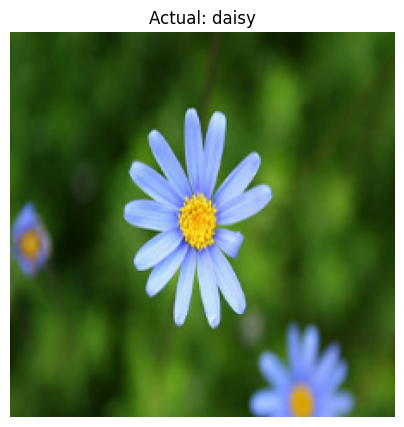

In [21]:
plt.figure(figsize=(5, 5))

plt.imshow(sample_image.numpy().astype("uint8"))

plt.title("Actual: " + actual_label)
plt.axis("off")

plt.show()

In [22]:
from PIL import Image

img_array = sample_image.numpy().astype("uint8")

pil_image = Image.fromarray(img_array)

print("Image converted successfully!")

Image converted successfully!


In [23]:
results = classifier(pil_image)

print("Hugging Face Predictions:")

for result in results[:5]:
    print(result)

Hugging Face Predictions:
{'label': 'daisy', 'score': 0.9428474307060242}
{'label': 'jay', 'score': 0.0015404991572722793}
{'label': 'maypole', 'score': 0.0006216629408299923}
{'label': 'prairie chicken, prairie grouse, prairie fowl', 'score': 0.0004522819654084742}
{'label': 'pole', 'score': 0.00044222784345038235}


In [24]:
resnet_prediction = model.predict(
    np.expand_dims(sample_image.numpy(), axis=0)
)

resnet_class = dataset.class_names[
    np.argmax(resnet_prediction[0])
]

print("Actual class:", actual_label)
print("ResNet-50 prediction:", resnet_class)
print("Hugging Face top prediction:", results[0]["label"])
print("Hugging Face confidence:", results[0]["score"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Actual class: daisy
ResNet-50 prediction: daisy
Hugging Face top prediction: daisy
Hugging Face confidence: 0.9428474307060242


In [25]:
import pandas as pd

results_table = pd.DataFrame({
    "Epoch": range(1, 11),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

results_table

,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,0.666016,0.843750,0.933082,0.463273
1,2,0.839453,0.863971,0.454604,0.414609
2,3,0.863672,0.897059,0.374975,0.329165
3,4,0.874609,0.902574,0.333050,0.293314
4,5,0.898047,0.902574,0.275401,0.297962
5,6,0.917578,0.924632,0.230488,0.245008
6,7,0.934375,0.906250,0.209228,0.303688
7,8,0.935547,0.906250,0.193420,0.280603
8,9,0.932031,0.922794,0.192996,0.264772
9,10,0.945703,0.909926,0.161757,0.260472


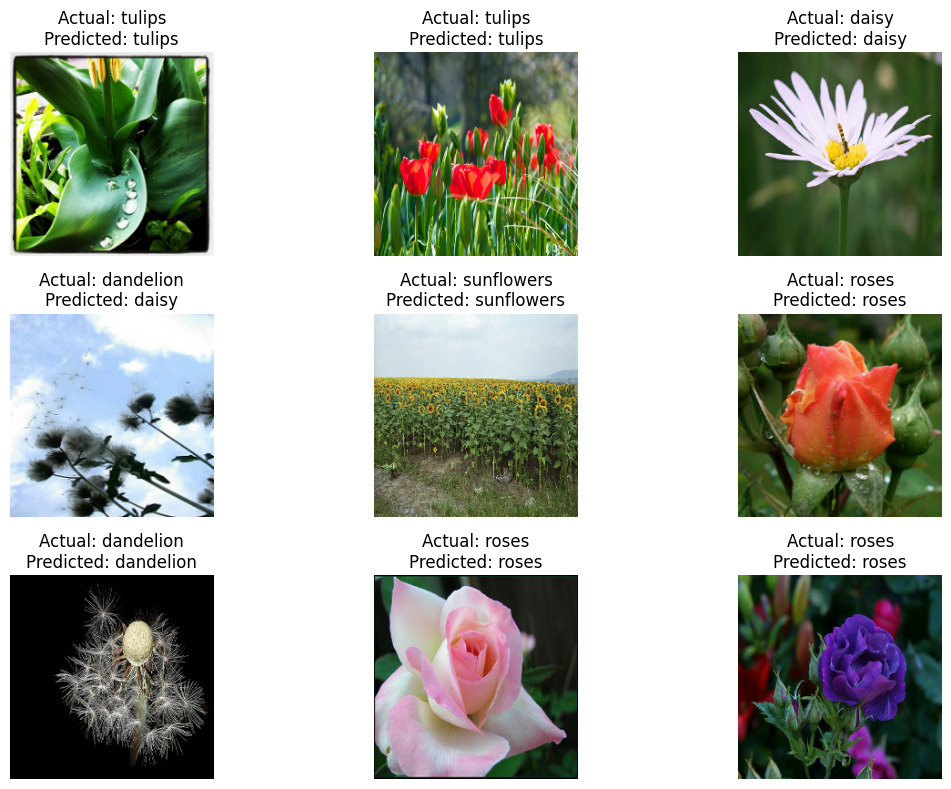

In [26]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for images, labels in test_ds.take(1):

    predictions = model.predict(images, verbose=0)

    for i in range(9):

        plt.subplot(3, 3, i + 1)

        # Display image
        plt.imshow(images[i].numpy().astype("uint8"))

        # Get predicted and actual class
        predicted_class = dataset.class_names[np.argmax(predictions[i])]
        actual_class = dataset.class_names[int(labels[i].numpy())]

        plt.title(
            f"Actual: {actual_class}\nPredicted: {predicted_class}"
        )

        plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

results_table = pd.DataFrame({
    "Epoch": range(1, 11),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

# Convert accuracy to percentage
results_table["Training Accuracy"] = results_table["Training Accuracy"] * 100
results_table["Validation Accuracy"] = results_table["Validation Accuracy"] * 100

# Round values
results_table["Training Accuracy"] = results_table["Training Accuracy"].round(2)
results_table["Validation Accuracy"] = results_table["Validation Accuracy"].round(2)
results_table["Training Loss"] = results_table["Training Loss"].round(4)
results_table["Validation Loss"] = results_table["Validation Loss"].round(4)

results_table

,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,66.60,84.38,0.9331,0.4633
1,2,83.95,86.40,0.4546,0.4146
2,3,86.37,89.71,0.3750,0.3292
3,4,87.46,90.26,0.3331,0.2933
4,5,89.80,90.26,0.2754,0.2980
5,6,91.76,92.46,0.2305,0.2450
6,7,93.44,90.62,0.2092,0.3037
7,8,93.55,90.62,0.1934,0.2806
8,9,93.20,92.28,0.1930,0.2648
9,10,94.57,90.99,0.1618,0.2605


In [28]:
import pandas as pd

results_table = pd.DataFrame({
    "Epoch": range(1, 11),
    "Training Accuracy": history.history["accuracy"],
    "Validation Accuracy": history.history["val_accuracy"],
    "Training Loss": history.history["loss"],
    "Validation Loss": history.history["val_loss"]
})

results_table["Training Accuracy"] = (
    results_table["Training Accuracy"] * 100
).round(2)

results_table["Validation Accuracy"] = (
    results_table["Validation Accuracy"] * 100
).round(2)

results_table["Training Loss"] = results_table["Training Loss"].round(4)
results_table["Validation Loss"] = results_table["Validation Loss"].round(4)

results_table

,Epoch,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,66.60,84.38,0.9331,0.4633
1,2,83.95,86.40,0.4546,0.4146
2,3,86.37,89.71,0.3750,0.3292
3,4,87.46,90.26,0.3331,0.2933
4,5,89.80,90.26,0.2754,0.2980
5,6,91.76,92.46,0.2305,0.2450
6,7,93.44,90.62,0.2092,0.3037
7,8,93.55,90.62,0.1934,0.2806
8,9,93.20,92.28,0.1930,0.2648
9,10,94.57,90.99,0.1618,0.2605


In [29]:
print("===== FINAL RESULTS =====")

print("Test Accuracy:", round(test_accuracy * 100, 2), "%")
print("Test Loss:", round(test_loss, 4))

best_epoch = results_table["Validation Accuracy"].idxmax() + 1
best_val = results_table["Validation Accuracy"].max()

print("Best Validation Accuracy:", best_val, "%")
print("Best Validation Epoch:", best_epoch)

print("Final Training Accuracy:",
      results_table["Training Accuracy"].iloc[-1], "%")

print("Final Validation Accuracy:",
      results_table["Validation Accuracy"].iloc[-1], "%")

===== FINAL RESULTS =====
Test Accuracy: 87.63 %
Test Loss: 0.3639
Best Validation Accuracy: 92.46 %
Best Validation Epoch: 6
Final Training Accuracy: 94.57 %
Final Validation Accuracy: 90.99 %
